# 🌾 HUẤN LUYỆN MÔ HÌNH HỒI QUY TUYẾN TÍNH ƯỚC LƯỢNG SỐ HẠT LÚA (31 FEATURES)
### ĐỀ TÀI NGHIÊN CỨU KHOA HỌC: HỆ THỐNG THỊ GIÁC MÁY TÍNH & HỌC SÂU ĐÁNH GIÁ PHẨM CẤP VÀ ĐẾM HẠT GIỐNG LÚA

---

### 🎯 Mục Tiêu & Điểm Nhấn Của Pipeline Huấn Luyện:
1. **Tận dụng tối đa toàn bộ 31 thuộc tính gốc** được trích xuất từ dữ liệu thực tế và AI (Vật chứa, Bề mặt, Kích thước 2D/3D: Mean, Min, Max, Std).
2. **Huấn luyện và so sánh chéo 13 biến thể Hồi Quy (Tuyến Tính + Phi Tuyến)**:
   - Ordinary Least Squares (OLS) Linear Regression
   - Ridge Regression (L2 Regularization)
   - Lasso Regression (L1 Regularization)
   - ElasticNet Regression (L1 + L2)
   - Huber Regressor (Kháng ngoại lai Robust)
   - Bayesian Ridge Regression (Hồi quy Bayes)
3. **Kiểm tra chéo 5-Fold Cross Validation** trên toàn bộ dữ liệu đảm bảo không bị quá khớp (Overfitting).
4. **Trực quan hóa Đỉnh cao**: Parity Plot ($Actual$ vs $Predicted$), Residuals Analysis, Biểu đồ thanh ngang 31 trọng số $\beta_i$.
5. **Xuất Phương Trình Toán Học & Model Artifacts**: Tự động lưu mô hình `.joblib`, `scaler.joblib`, và tệp JSON chứa phương trình hồi quy tường minh để nhúng vào bất kỳ ứng dụng nào!


In [1]:
# Bước 1: Kết nối Google Drive & Cài đặt thư viện huấn luyện Machine Learning
from google.colab import drive
import os

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

!pip install pandas numpy scikit-learn matplotlib seaborn joblib openpyxl scipy xgboost


Mounted at /content/drive


In [2]:
# Bước 2: Khai báo Đường dẫn, Nạp Dữ liệu & Chuẩn bị Ma trận X (31 Features) và y (Actual_Count)
import os
import sys
import json
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

# Cài đặt giao diện đồ thị khoa học chuẩn mực
sns.set_theme(style="whitegrid", font_scale=1.02)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ĐƯỜNG DẪN DỰ ÁN
BASE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES"
DATA_CSV_PATH = os.path.join(BASE_PATH, "DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.csv")
DATA_EXCEL_PATH = os.path.join(BASE_PATH, "DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.xlsx")

OUTPUT_MODEL_DIR = os.path.join(BASE_PATH, "LINEAR_REGRESSION_MODEL/models")
OUTPUT_RESULT_DIR = os.path.join(BASE_PATH, "LINEAR_REGRESSION_MODEL/results")
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_RESULT_DIR, exist_ok=True)

if os.path.exists(DATA_CSV_PATH):
    df_raw = pd.read_csv(DATA_CSV_PATH)
elif os.path.exists(DATA_EXCEL_PATH):
    df_raw = pd.read_excel(DATA_EXCEL_PATH)
else:
    df_raw = pd.read_csv("DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.csv")

# Lọc lấy các mẫu hợp lệ đã trích xuất AI (Image_Status == 'FOUND')
df = df_raw[df_raw['Image_Status'] == 'FOUND'].copy()

# Danh sách toàn bộ 31 thuộc tính gốc
ALL_31_FEATURES = [
    # Nhóm 1: Vật chứa & Thể tích khối lúa (8 biến)
    'Bulk_Rice_Volume_mm3', 'Rice_Height_mm', 'Weight_g', 'Empty_Height_mm',
    'Pixels_Per_mm', 'Container_Detected_Diam_px', 'Inner_Diameter_mm', 'Container_Height_mm',
    # Nhóm 2: Bề mặt & Ước lượng (3 biến)
    'Whole_Grains_Count', 'Uniformity_Rate_Pct', 'Estimated_Total_Seeds_Hybrid',
    # Nhóm 3: Chiều dài hạt 2a (4 biến)
    'Grain_Length_mm_Mean', 'Grain_Length_mm_Min', 'Grain_Length_mm_Max', 'Grain_Length_mm_Std',
    # Nhóm 4: Chiều rộng hạt 2b (4 biến)
    'Grain_Width_mm_Mean', 'Grain_Width_mm_Min', 'Grain_Width_mm_Max', 'Grain_Width_mm_Std',
    # Nhóm 5: Chiều dày hạt 2c (4 biến)
    'Grain_Thickness_mm_Mean', 'Grain_Thickness_mm_Min', 'Grain_Thickness_mm_Max', 'Grain_Thickness_mm_Std',
    # Nhóm 6: Diện tích 2D (4 biến)
    'Grain_Area_mm2_Mean', 'Grain_Area_mm2_Min', 'Grain_Area_mm2_Max', 'Grain_Area_mm2_Std',
    # Nhóm 7: Thể tích 3D Hạt (4 biến)
    'Grain_Volume_mm3_Mean', 'Grain_Volume_mm3_Min', 'Grain_Volume_mm3_Max', 'Grain_Volume_mm3_Std'
]

TARGET_COL = 'Actual_Count'

# Chuyển đổi kiểu số
for col in ALL_31_FEATURES + [TARGET_COL]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna(subset=ALL_31_FEATURES + [TARGET_COL])

X = df_clean[ALL_31_FEATURES].values
y = df_clean[TARGET_COL].values
sample_ids = df_clean['Sample_ID'].values

print("=" * 95)
print("📊 TỔNG QUAN TẬP DỮ LIỆU ĐƯA VÀO HUẤN LUYỆN:")
print("=" * 95)
print(f"🔹 Tổng số mẫu hợp lệ : {len(df_clean)} mẫu")
print(f"🔹 Số chiều đặc trưng : {X.shape[1]} thuộc tính gốc")
print(f"🔹 Biến mục tiêu (Y)  : '{TARGET_COL}' (Số hạt lúa thực tế)")
print(f"🔹 Dải giá trị Y      : Từ {y.min():.0f} đến {y.max():.0f} hạt (Mean={y.mean():.1f}, Median={np.median(y):.1f})")
print("=" * 95)


📊 TỔNG QUAN TẬP DỮ LIỆU ĐƯA VÀO HUẤN LUYỆN:
🔹 Tổng số mẫu hợp lệ : 254 mẫu
🔹 Số chiều đặc trưng : 31 thuộc tính gốc
🔹 Biến mục tiêu (Y)  : 'Actual_Count' (Số hạt lúa thực tế)
🔹 Dải giá trị Y      : Từ 25 đến 305 hạt (Mean=163.1, Median=157.5)


In [3]:
# Bước 3: Phân Chia Tập Train (80%) / Test (20%) & Chuẩn Hóa StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test, sids_train, sids_test = train_test_split(
    X, y, sample_ids, test_size=0.20, random_state=42, shuffle=True
)

# Chuẩn hóa Z-Score trên tập Train (fit) và biến đổi cho cả Train và Test (transform)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lưu scaler model
scaler_joblib_path = os.path.join(OUTPUT_MODEL_DIR, "scaler.joblib")
joblib.dump(scaler, scaler_joblib_path)

# Lưu tham số scaler dạng JSON
scaler_json_path = os.path.join(OUTPUT_MODEL_DIR, "scaler_params.json")
with open(scaler_json_path, "w", encoding="utf-8") as f:
    json.dump({
        "features": ALL_31_FEATURES,
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist()
    }, f, ensure_ascii=False, indent=2)

print("=" * 95)
print(f"🔹 Tập Huấn Luyện (Train Set): {len(X_train)} mẫu (80.0%)")
print(f"🔹 Tập Kiểm Thử  (Test Set) : {len(X_test)} mẫu (20.0%)")
print(f"💾 Đã lưu StandardScaler vào : {scaler_joblib_path}")
print("=" * 95)


🔹 Tập Huấn Luyện (Train Set): 203 mẫu (80.0%)
🔹 Tập Kiểm Thử  (Test Set) : 51 mẫu (20.0%)
💾 Đã lưu StandardScaler vào : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/models/scaler.joblib


In [4]:
# Bước 4: HUẤN LUYỆN & SO SÁNH CHÉO 13 BIẾN THỂ HỒI QUY (TUYẾN TÍNH + PHI TUYẾN, 5-FOLD CV)
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge,
    ARDRegression, RidgeCV
)
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

kf = KFold(n_splits=5, shuffle=True, random_state=42)
N_features = X_train.shape[1]

# --- Nhóm A: 6 mô hình Hồi Quy Tuyến Tính chuẩn mực (baseline gốc) ---
models_dict = {
    "1. Ridge Regression (L2 - alpha=0.1)": Ridge(alpha=0.1, random_state=42),
    "2. Ordinary Least Squares (OLS)": LinearRegression(),
    "3. Ridge Regularized (L2 - alpha=1.0)": Ridge(alpha=1.0, random_state=42),
    "4. Bayesian Ridge Regression": BayesianRidge(),
    "5. Huber Regressor (Kháng ngoại lai)": HuberRegressor(max_iter=1000),
    "6. ElasticNet (L1 + L2 Combo)": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
}

# --- Nhóm B: 4 biến thể nâng cao (vẫn thuộc họ tuyến tính / kernel) ---
# Tìm số thành phần PLS tối ưu bằng CV trước
best_pls_score, best_n_comp = -np.inf, 2
for n_comp in range(2, min(15, N_features)):
    score = cross_val_score(PLSRegression(n_components=n_comp), X_train_scaled, y_train, cv=kf, scoring='r2').mean()
    if score > best_pls_score:
        best_pls_score, best_n_comp = score, n_comp

models_dict.update({
    f"7. PLS Regression (n_components={best_n_comp})": PLSRegression(n_components=best_n_comp),
    "8. ARD Regression (Bayesian Sparse)": ARDRegression(),
    "9. Kernel Ridge (RBF Kernel)": KernelRidge(kernel='rbf', alpha=1.0, gamma=None),
    "10. Stacking (OLS+Ridge+BayesianRidge -> RidgeCV)": StackingRegressor(
        estimators=[
            ('ols', LinearRegression()),
            ('ridge', Ridge(alpha=0.1, random_state=42)),
            ('bridge', BayesianRidge()),
        ],
        final_estimator=RidgeCV(alphas=np.logspace(-3, 3, 20)),
        cv=kf
    ),
})

# --- Nhóm C: 3 mô hình Ensemble Phi Tuyến (giới hạn trên của độ chính xác) ---
models_dict.update({
    "11. Random Forest Regressor": RandomForestRegressor(
        n_estimators=500, max_depth=None, min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    "12. Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=3, subsample=0.8, random_state=42
    ),
})
if HAS_XGB:
    models_dict["13. XGBoost Regressor"] = XGBRegressor(
        n_estimators=600, learning_rate=0.03, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1
    )

leaderboard_records = []
fitted_models = {}
model_test_preds = {}

for model_name, model in models_dict.items():
    # 1. 5-Fold Cross Validation trên tập Train
    cv_r2 = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2', n_jobs=-1)
    cv_mae = -cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

    # 2. Huấn luyện trên toàn bộ tập Train
    model.fit(X_train_scaled, y_train)
    fitted_models[model_name] = model

    # 3. Dự đoán trên tập Train và Test (ravel để xử lý PLS trả về mảng 2D)
    y_tr_pred = np.ravel(model.predict(X_train_scaled))
    y_te_pred = np.ravel(model.predict(X_test_scaled))
    model_test_preds[model_name] = y_te_pred

    # 4. Tính toán các chỉ số đánh giá (đã bổ sung MSE_Test)
    r2_tr = r2_score(y_train, y_tr_pred)
    r2_te = r2_score(y_test, y_te_pred)

    n_te = len(y_test)
    adj_r2_te = 1.0 - ((1.0 - r2_te) * (n_te - 1) / (n_te - N_features - 1)) if (n_te - N_features - 1) > 0 else r2_te

    mae_te = mean_absolute_error(y_test, y_te_pred)
    mse_te = mean_squared_error(y_test, y_te_pred)
    rmse_te = np.sqrt(mse_te)
    mape_te = np.mean(np.abs((y_test - y_te_pred) / y_test)) * 100
    max_err_te = np.max(np.abs(y_test - y_te_pred))

    leaderboard_records.append({
        'Mô_Hình_Hồi_Quy': model_name,
        'R2_Train': round(r2_tr, 4),
        'R2_CV_5Fold': round(np.mean(cv_r2), 4),
        'R2_Test': round(r2_te, 4),
        'Adj_R2_Test': round(adj_r2_te, 4),
        'MAE_Test (hạt)': round(mae_te, 2),
        'MSE_Test (hạt²)': round(mse_te, 2),
        'RMSE_Test (hạt)': round(rmse_te, 2),
        'MAPE_Test (%)': round(mape_te, 2),
        'Max_Error (hạt)': round(max_err_te, 2)
    })

df_leaderboard = pd.DataFrame(leaderboard_records).sort_values(by='RMSE_Test (hạt)', ascending=True).reset_index(drop=True)
df_leaderboard.index = df_leaderboard.index + 1

print("=" * 130)
print(f"🏆 BẢNG TỔNG KẾT SO SÁNH HIỆU NĂNG {len(leaderboard_records)} MÔ HÌNH HỒI QUY (TOÀN BỘ 31 FEATURES), sắp xếp theo RMSE thấp nhất:")
print("=" * 130)
display(df_leaderboard)

# Xuất bảng so sánh ra CSV
report_csv_path = os.path.join(OUTPUT_RESULT_DIR, "training_evaluation_report.csv")
df_leaderboard.to_csv(report_csv_path, index=False, encoding="utf-8-sig")
print(f"💾 Đã lưu bảng so sánh mô hình vào: {report_csv_path}")

# Top 10 feature quan trọng theo Random Forest (nếu có huấn luyện)
if "11. Random Forest Regressor" in fitted_models:
    rf_importance = pd.Series(
        fitted_models["11. Random Forest Regressor"].feature_importances_,
        index=ALL_31_FEATURES
    ).sort_values(ascending=False)
    print("\n📊 Top 10 feature quan trọng nhất theo Random Forest:")
    print(rf_importance.head(10))


🏆 BẢNG TỔNG KẾT SO SÁNH HIỆU NĂNG 13 MÔ HÌNH HỒI QUY (TOÀN BỘ 31 FEATURES), sắp xếp theo RMSE thấp nhất:


,Mô_Hình_Hồi_Quy,R2_Train,R2_CV_5Fold,R2_Test,Adj_R2_Test,MAE_Test (hạt),MSE_Test (hạt²),RMSE_Test (hạt),MAPE_Test (%),Max_Error (hạt)
1,12. Gradient Boosting Regressor,1.0000,0.9998,0.9998,0.9994,0.66,1.60,1.26,0.58,4.07
2,13. XGBoost Regressor,1.0000,0.9996,0.9996,0.9990,0.83,2.48,1.58,0.74,5.62
3,11. Random Forest Regressor,0.9999,0.9993,0.9993,0.9981,1.49,4.87,2.21,1.19,6.41
4,8. ARD Regression (Bayesian Sparse),0.9993,0.9993,0.9990,0.9974,1.79,6.70,2.59,1.97,8.44
5,2. Ordinary Least Squares (OLS),0.9994,0.8524,0.9990,0.9973,1.91,7.09,2.66,2.02,8.32
6,4. Bayesian Ridge Regression,0.9993,0.9985,0.9989,0.9972,1.90,7.32,2.71,2.14,7.74
7,10. Stacking (OLS+Ridge+BayesianRidge -> RidgeCV),0.9993,0.9987,0.9989,0.9970,1.98,7.82,2.80,2.23,7.43
8,1. Ridge Regression (L2 - alpha=0.1),0.9993,0.9989,0.9988,0.9968,2.10,8.37,2.89,2.32,7.31
9,7. PLS Regression (n_components=13),0.9992,0.9989,0.9987,0.9967,2.27,8.64,2.94,2.32,6.66
10,5. Huber Regressor (Kháng ngoại lai),0.9992,0.9977,0.9979,0.9944,2.28,14.38,3.79,2.80,10.57


💾 Đã lưu bảng so sánh mô hình vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/results/training_evaluation_report.csv

📊 Top 10 feature quan trọng nhất theo Random Forest:
Weight_g                        0.470444
Bulk_Rice_Volume_mm3            0.452337
Rice_Height_mm                  0.037783
Empty_Height_mm                 0.029158
Inner_Diameter_mm               0.007777
Container_Height_mm             0.001738
Estimated_Total_Seeds_Hybrid    0.000119
Pixels_Per_mm                   0.000050
Container_Detected_Diam_px      0.000049
Grain_Area_mm2_Min              0.000040
dtype: float64


In [5]:
# Bước 5: CHỌN MÔ HÌNH TỐI ƯU NHẤT & TRÍCH XUẤT PHƯƠNG TRÌNH (NẾU LÀ MÔ HÌNH TUYẾN TÍNH)
best_model_name = df_leaderboard.iloc[0]['Mô_Hình_Hồi_Quy']
best_model = fitted_models[best_model_name]

# Một số mô hình (Stacking, KernelRidge, PLS, RandomForest, GBM, XGBoost) KHÔNG có .coef_ chuẩn
# -> chỉ trích xuất phương trình tường minh nếu mô hình tốt nhất thuộc họ tuyến tính có .coef_
is_linear_explicit = hasattr(best_model, 'coef_') and np.ndim(np.ravel(best_model.coef_)) == 1 \
                      and len(np.ravel(best_model.coef_)) == len(ALL_31_FEATURES)

print("=" * 100)
print(f"🌟 MÔ HÌNH TỐT NHẤT ĐƯỢC CHỌN (theo RMSE_Test thấp nhất): {best_model_name}")
print("=" * 100)

if is_linear_explicit:
    scaled_coefs = np.ravel(best_model.coef_)
    scaled_intercept = float(np.ravel(best_model.intercept_)[0]) if np.ndim(best_model.intercept_) else float(best_model.intercept_)

    # Chuyển đổi về không gian biến gốc thực tế (Unscaled Original Equation)
    unscaled_coefs = scaled_coefs / scaler.scale_
    unscaled_intercept = scaled_intercept - np.sum(scaled_coefs * scaler.mean_ / scaler.scale_)

    equation_dict = {
        "model_name": best_model_name,
        "target_variable": TARGET_COL,
        "number_of_features": len(ALL_31_FEATURES),
        "r2_score_test": float(df_leaderboard.iloc[0]['R2_Test']),
        "mae_test": float(df_leaderboard.iloc[0]['MAE_Test (hạt)']),
        "mse_test": float(df_leaderboard.iloc[0]['MSE_Test (hạt²)']),
        "rmse_test": float(df_leaderboard.iloc[0]['RMSE_Test (hạt)']),
        "mape_test": float(df_leaderboard.iloc[0]['MAPE_Test (%)']),
        "intercept": float(unscaled_intercept),
        "features": []
    }

    print(f"📐 PHƯƠNG TRÌNH HỒI QUY TOÁN HỌC HOÀN CHỈNH:")
    print(f"Số_Hạt_Dự_Đoán (Actual_Count) = {unscaled_intercept:+.4f}")

    for i, feat in enumerate(ALL_31_FEATURES):
        w_sc = float(scaled_coefs[i])
        w_un = float(unscaled_coefs[i])
        equation_dict["features"].append({
            "name": feat,
            "standardized_weight": w_sc,
            "unscaled_coefficient": w_un,
            "mean": float(scaler.mean_[i]),
            "scale": float(scaler.scale_[i])
        })
        sign = "+" if w_un >= 0 else "-"
        print(f"   {sign} ({abs(w_un):.6f} * {feat})")
    print("=" * 100 + "\n")

    eq_json_path = os.path.join(OUTPUT_MODEL_DIR, "regression_equation.json")
    with open(eq_json_path, "w", encoding="utf-8") as f:
        json.dump(equation_dict, f, ensure_ascii=False, indent=2)
    print(f"💾 Đã lưu phương trình JSON vào: {eq_json_path}")
else:
    print("ℹ️  Mô hình tốt nhất không có hệ số tuyến tính tường minh (VD: Random Forest, GBM, XGBoost,")
    print("    Kernel Ridge, PLS hoặc Stacking) -> bỏ qua bước xuất phương trình toán học.")
    print(f"    RMSE_Test  = {df_leaderboard.iloc[0]['RMSE_Test (hạt)']} hạt")
    print(f"    MAE_Test   = {df_leaderboard.iloc[0]['MAE_Test (hạt)']} hạt")
    print(f"    MSE_Test   = {df_leaderboard.iloc[0]['MSE_Test (hạt²)']} hạt²")
    print("=" * 100 + "\n")

    # Nếu vẫn cần một phương trình tuyến tính tường minh song song, lấy mô hình tuyến tính tốt nhất
    linear_rows = df_leaderboard[df_leaderboard['Mô_Hình_Hồi_Quy'].isin(
        [n for n in fitted_models if hasattr(fitted_models[n], 'coef_')
         and np.ndim(np.ravel(fitted_models[n].coef_)) == 1
         and len(np.ravel(fitted_models[n].coef_)) == len(ALL_31_FEATURES)]
    )]
    if not linear_rows.empty:
        best_linear_name = linear_rows.iloc[0]['Mô_Hình_Hồi_Quy']
        print(f"📌 Mô hình tuyến tính tốt nhất song song (để lấy phương trình): {best_linear_name} "
              f"(RMSE_Test={linear_rows.iloc[0]['RMSE_Test (hạt)']})")

# Lưu file mô hình tốt nhất (luôn lưu, dù tuyến tính hay không)
best_joblib_path = os.path.join(OUTPUT_MODEL_DIR, "best_regression_model.joblib")
joblib.dump(best_model, best_joblib_path)
print(f"💾 Đã lưu trọng số mô hình tốt nhất vào : {best_joblib_path}")


🌟 MÔ HÌNH TỐT NHẤT ĐƯỢC CHỌN (theo RMSE_Test thấp nhất): 12. Gradient Boosting Regressor
ℹ️  Mô hình tốt nhất không có hệ số tuyến tính tường minh (VD: Random Forest, GBM, XGBoost,
    Kernel Ridge, PLS hoặc Stacking) -> bỏ qua bước xuất phương trình toán học.
    RMSE_Test  = 1.26 hạt
    MAE_Test   = 0.66 hạt
    MSE_Test   = 1.6 hạt²

📌 Mô hình tuyến tính tốt nhất song song (để lấy phương trình): 8. ARD Regression (Bayesian Sparse) (RMSE_Test=2.59)
💾 Đã lưu trọng số mô hình tốt nhất vào : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/models/best_regression_model.joblib


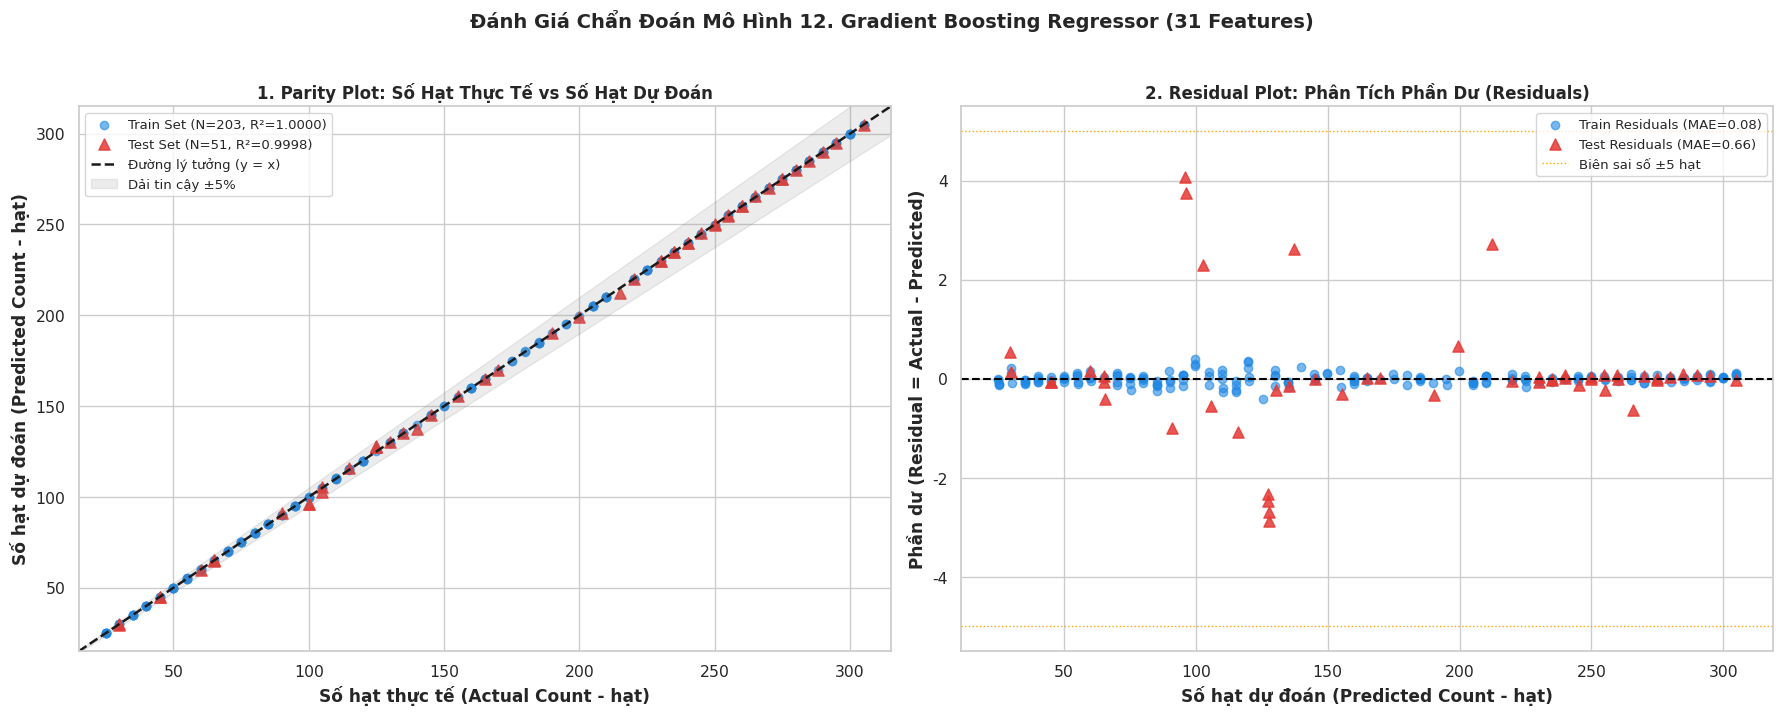

💾 Đã lưu biểu đồ Parity & Residual vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/results/1_model_diagnostic_parity_residual_plots.png


In [6]:
# Bước 6: TRỰC QUAN HÓA ĐÁNH GIÁ MÔ HÌNH (PARITY PLOT & RESIDUALS ANALYSIS)
y_tr_pred = best_model.predict(X_train_scaled)
y_te_pred = best_model.predict(X_test_scaled)

residuals_train = y_train - y_tr_pred
residuals_test = y_test - y_te_pred

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Parity Plot: Actual vs Predicted
min_val = min(y.min(), y_te_pred.min()) - 10
max_val = max(y.max(), y_te_pred.max()) + 10

axes[0].scatter(y_train, y_tr_pred, color='#1E88E5', alpha=0.6, label=f'Train Set (N={len(y_train)}, R²={r2_score(y_train, y_tr_pred):.4f})')
axes[0].scatter(y_test, y_te_pred, color='#E53935', alpha=0.85, marker='^', s=65, label=f'Test Set (N={len(y_test)}, R²={r2_score(y_test, y_te_pred):.4f})')
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.8, label='Đường lý tưởng (y = x)')
axes[0].fill_between([min_val, max_val], [min_val*0.95, max_val*0.95], [min_val*1.05, max_val*1.05], color='gray', alpha=0.15, label='Dải tin cậy ±5%')
axes[0].set_title("1. Parity Plot: Số Hạt Thực Tế vs Số Hạt Dự Đoán", fontweight='bold', fontsize=12)
axes[0].set_xlabel("Số hạt thực tế (Actual Count - hạt)", fontweight='bold')
axes[0].set_ylabel("Số hạt dự đoán (Predicted Count - hạt)", fontweight='bold')
axes[0].set_xlim(min_val, max_val)
axes[0].set_ylim(min_val, max_val)
axes[0].legend(loc='upper left', fontsize=9.5)

# 2. Residual Plot: Phần dư vs Giá trị dự đoán
axes[1].scatter(y_tr_pred, residuals_train, color='#1E88E5', alpha=0.6, label=f'Train Residuals (MAE={mean_absolute_error(y_train, y_tr_pred):.2f})')
axes[1].scatter(y_te_pred, residuals_test, color='#E53935', alpha=0.85, marker='^', s=65, label=f'Test Residuals (MAE={mean_absolute_error(y_test, y_te_pred):.2f})')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].axhline(5, color='orange', linewidth=1, linestyle=':')
axes[1].axhline(-5, color='orange', linewidth=1, linestyle=':', label='Biên sai số ±5 hạt')
axes[1].set_title("2. Residual Plot: Phân Tích Phần Dư (Residuals)", fontweight='bold', fontsize=12)
axes[1].set_xlabel("Số hạt dự đoán (Predicted Count - hạt)", fontweight='bold')
axes[1].set_ylabel("Phần dư (Residual = Actual - Predicted)", fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9.5)

plt.suptitle(f"Đánh Giá Chẩn Đoán Mô Hình {best_model_name} (31 Features)", fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
diag_path = os.path.join(OUTPUT_RESULT_DIR, "1_model_diagnostic_parity_residual_plots.png")
plt.savefig(diag_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Đã lưu biểu đồ Parity & Residual vào: {diag_path}")


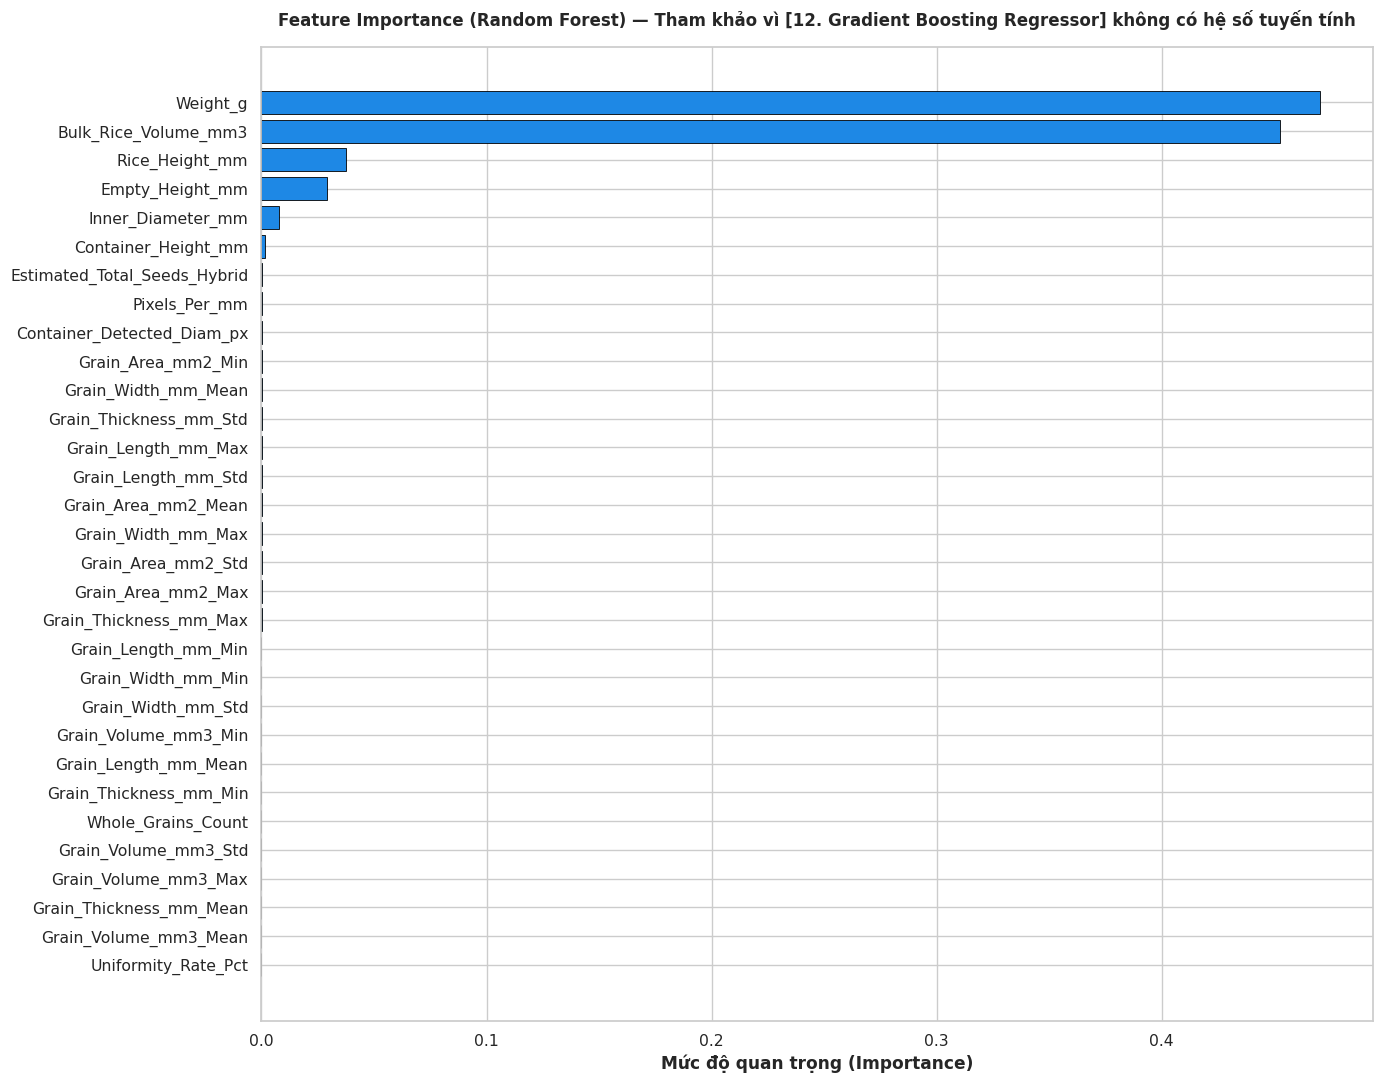

💾 Đã lưu biểu đồ feature importance vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/results/2_feature_importance_chart.png


In [7]:
# Bước 7: TRỰC QUAN HÓA TRỌNG SỐ HỆ SỐ HỒI QUY (CHỈ ÁP DỤNG NẾU MÔ HÌNH TỐT NHẤT LÀ TUYẾN TÍNH TƯỜNG MINH)
if is_linear_explicit:
    sorted_idx = np.argsort(np.abs(scaled_coefs))[::-1]
    feat_sorted = [ALL_31_FEATURES[i] for i in sorted_idx]
    weights_sorted = scaled_coefs[sorted_idx]
    colors = ['#1E88E5' if w >= 0 else '#E53935' for w in weights_sorted]

    plt.figure(figsize=(14, 11))
    bars = plt.barh(feat_sorted[::-1], weights_sorted[::-1], color=colors[::-1], edgecolor='black', linewidth=0.6)
    plt.axvline(0, color='black', linewidth=1.2)
    plt.title(f"Trọng Số Chuẩn Hóa (Standardized Beta Coefficients) Của Toàn Bộ 31 Thuộc Tính\n[{best_model_name}]", fontweight='bold', fontsize=13, pad=15)
    plt.xlabel("Hệ Số Trọng Số Chuẩn Hóa (Beta Weight)", fontweight='bold')

    patch_pos = plt.Rectangle((0,0),1,1, color='#1E88E5', label='Tác động thuận (+) đến số hạt')
    patch_neg = plt.Rectangle((0,0),1,1, color='#E53935', label='Tác động nghịch (-) đến số hạt')
    plt.legend(handles=[patch_pos, patch_neg], loc='lower right', fontsize=10.5)

    plt.tight_layout()
    weights_chart_path = os.path.join(OUTPUT_RESULT_DIR, "2_all_31_features_weights_chart.png")
    plt.savefig(weights_chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Đã lưu biểu đồ trọng số 31 thuộc tính vào: {weights_chart_path}")
elif "11. Random Forest Regressor" in fitted_models:
    # Fallback: hiển thị Feature Importance nếu mô hình tốt nhất là ensemble cây
    importances = fitted_models["11. Random Forest Regressor"].feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    feat_sorted = [ALL_31_FEATURES[i] for i in sorted_idx]
    imp_sorted = importances[sorted_idx]

    plt.figure(figsize=(14, 11))
    plt.barh(feat_sorted[::-1], imp_sorted[::-1], color='#1E88E5', edgecolor='black', linewidth=0.6)
    plt.title(f"Feature Importance (Random Forest) — Tham khảo vì [{best_model_name}] không có hệ số tuyến tính", fontweight='bold', fontsize=12, pad=15)
    plt.xlabel("Mức độ quan trọng (Importance)", fontweight='bold')
    plt.tight_layout()
    weights_chart_path = os.path.join(OUTPUT_RESULT_DIR, "2_feature_importance_chart.png")
    plt.savefig(weights_chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Đã lưu biểu đồ feature importance vào: {weights_chart_path}")
else:
    print("ℹ️  Bỏ qua biểu đồ trọng số vì mô hình tốt nhất không hỗ trợ hệ số tuyến tính hay feature_importances_.")


In [8]:
# Bước 8: XUẤT BẢNG KẾT QUẢ DỰ ĐOÁN CHI TIẾT TẬP KIỂM THỬ (TEST SET)
df_test_results = pd.DataFrame({
    'Sample_ID': sids_test,
    'Actual_Count': y_test,
    'Predicted_Count': np.round(y_te_pred, 2),
    'Error_Seeds': np.round(y_te_pred - y_test, 2),
    'Abs_Error': np.round(np.abs(y_te_pred - y_test), 2),
    'Percentage_Error_%': np.round(np.abs((y_te_pred - y_test) / y_test) * 100, 2)
}).sort_values(by='Abs_Error', ascending=False)

test_pred_csv = os.path.join(OUTPUT_RESULT_DIR, "test_set_predictions.csv")
df_test_results.to_csv(test_pred_csv, index=False, encoding="utf-8-sig")

print("=" * 95)
print(f"📋 [BẢNG 10 MẪU TEST DỰ ĐOÁN MẪU]:")
print("=" * 95)
display(df_test_results.head(10))
print(f"💾 Đã lưu toàn bộ bảng dự đoán tập Test vào: {test_pred_csv}")


📋 [BẢNG 10 MẪU TEST DỰ ĐOÁN MẪU]:


,Sample_ID,Actual_Count,Predicted_Count,Error_Seeds,Abs_Error,Percentage_Error_%
18,M020b,100,95.93,-4.07,4.07,4.07
31,M020c,100,96.25,-3.75,3.75,3.75
46,M004b,125,127.88,2.88,2.88,2.30
29,M039a,215,212.28,-2.72,2.72,1.27
37,M004d,125,127.69,2.69,2.69,2.15
22,M025a,140,137.39,-2.61,2.61,1.87
21,M004e,125,127.47,2.47,2.47,1.98
17,M004a,125,127.33,2.33,2.33,1.87
1,M002b,105,102.70,-2.30,2.30,2.19
28,M003a,115,116.07,1.07,1.07,0.93


💾 Đã lưu toàn bộ bảng dự đoán tập Test vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/results/test_set_predictions.csv


In [9]:
# Bước 9: THỬ NGHIỆM DỰ ĐOÁN TỨC THÌ CHO 1 MẪU MỚI (INTERACTIVE PREDICTION)
# Bạn có thể thay đổi bất kỳ giá trị nào dưới đây để kiểm tra kết quả dự đoán số hạt:
sample_test_input = {
    "Bulk_Rice_Volume_mm3": 5723.45,
    "Rice_Height_mm": 23.0,
    "Weight_g": 2.69,
    "Empty_Height_mm": 10.9,
    "Pixels_Per_mm": 37.15,
    "Container_Detected_Diam_px": 661.0,
    "Inner_Diameter_mm": 17.8,
    "Container_Height_mm": 33.9,
    "Whole_Grains_Count": 7.0,
    "Uniformity_Rate_Pct": 100.0,
    "Estimated_Total_Seeds_Hybrid": 141.0,
    "Grain_Length_mm_Mean": 5.33,
    "Grain_Length_mm_Min": 3.74,
    "Grain_Length_mm_Max": 6.87,
    "Grain_Length_mm_Std": 0.98,
    "Grain_Width_mm_Mean": 1.86,
    "Grain_Width_mm_Min": 1.56,
    "Grain_Width_mm_Max": 2.35,
    "Grain_Width_mm_Std": 0.29,
    "Grain_Thickness_mm_Mean": 4.53,
    "Grain_Thickness_mm_Min": 3.18,
    "Grain_Thickness_mm_Max": 5.84,
    "Grain_Thickness_mm_Std": 0.84,
    "Grain_Area_mm2_Mean": 7.38,
    "Grain_Area_mm2_Min": 5.38,
    "Grain_Area_mm2_Max": 11.40,
    "Grain_Area_mm2_Std": 2.29,
    "Grain_Volume_mm3_Mean": 25.19,
    "Grain_Volume_mm3_Min": 11.96,
    "Grain_Volume_mm3_Max": 49.25,
    "Grain_Volume_mm3_Std": 12.73
}

# Chuyển sample thành vector mảng
sample_vector = np.array([[sample_test_input[feat] for feat in ALL_31_FEATURES]])
sample_vector_scaled = scaler.transform(sample_vector)
predicted_count = best_model.predict(sample_vector_scaled)[0]

print("=" * 80)
print("🎯 KẾT QUẢ DỰ ĐOÁN SỐ LƯỢNG HẠT CHO MẪU:")
print("=" * 80)
print(f"🔹 Số hạt dự đoán (Predicted Count) : {int(round(predicted_count))} HẠT (Giá trị thô: {predicted_count:.2f})")
print(f"🔹 Độ tin cậy mô hình             : R² = {df_leaderboard.iloc[0]['R2_Test']} (Sai số MAE ~{df_leaderboard.iloc[0]['MAE_Test (hạt)']} hạt)")
print("=" * 80)


🎯 KẾT QUẢ DỰ ĐOÁN SỐ LƯỢNG HẠT CHO MẪU:
🔹 Số hạt dự đoán (Predicted Count) : 85 HẠT (Giá trị thô: 85.14)
🔹 Độ tin cậy mô hình             : R² = 0.9998 (Sai số MAE ~0.66 hạt)
